<a href="https://colab.research.google.com/github/su92-msaiw-f25-006-boop/lessons-learned/blob/main/Crop_Disease_Detection_Using_Convolutional_Autoencoder_(CAE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import TensorFlow
import tensorflow as tf

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU is available:", gpu_devices)
else:
    print("No GPU detected. Please enable GPU in Runtime settings.")


TensorFlow version: 2.19.0
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Data Handling
import numpy as np
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# Image Processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import warnings
warnings.filterwarnings("ignore")


In [3]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import necessary libraries
import os
import zipfile

# Path to the archive.zip file in Google Drive
zip_path = '/content/drive/MyDrive/archive.zip'  # CHANGE this if your zip is in another folder
extract_dir = '/content/PlantVillage'            # Folder where we will extract

# Step 3: Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset unzipped successfully!")

# Step 4: Inspect folder structure and list classes
dataset_dir = os.path.join(extract_dir, 'PlantVillage')  # adjust if inside folder another PlantVillage exists
classes = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

print("Detected classes:", classes)
print("Number of classes:", len(classes))


Mounted at /content/drive
Dataset unzipped successfully!
Detected classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


In [4]:
import shutil
from sklearn.model_selection import train_test_split

# Base folder to save splits
base_split_dir = '/content/drive/MyDrive/PlantVillage_Splits'  # permanent location

# Create folders for train, val, test
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_split_dir, split)
    os.makedirs(split_path, exist_ok=True)
    # Create subfolders for each class
    for cls in classes:
        os.makedirs(os.path.join(split_path, cls), exist_ok=True)

# Gather all image paths and their labels
image_paths = []
labels = []

for cls in classes:
    cls_path = os.path.join(dataset_dir, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(cls_path, img_file))
            labels.append(cls)

# First split: Train 70%, Temp 30%
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

# Second split: Validation 50% of temp, Test 50% of temp → 15% each
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# Function to copy files to their new folders
def copy_files(paths, labels, split_name):
    for src, label in zip(paths, labels):
        dst_dir = os.path.join(base_split_dir, split_name, label)
        shutil.copy(src, dst_dir)

# Copy the images
copy_files(train_paths, train_labels, 'train')
copy_files(val_paths, val_labels, 'val')
copy_files(test_paths, test_labels, 'test')

print("Dataset successfully split and saved to Google Drive!")


Dataset successfully split and saved to Google Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 128

def load_images(image_paths, labels, classes, img_size=IMG_SIZE):
    X = []
    y = []
    class_to_idx = {cls:i for i, cls in enumerate(classes)}
    for img_path, label in zip(image_paths, labels):
        img = load_img(img_path, target_size=(img_size, img_size))
        X.append(img_to_array(img)/255.0)
        y.append(class_to_idx[label])
    return np.array(X, dtype='float32'), np.array(y), class_to_idx

X_train, y_train, class_to_idx = load_images(train_paths, train_labels, classes)
X_val, y_val, _ = load_images(val_paths, val_labels, classes)
X_test, y_test, _ = load_images(test_paths, test_labels, classes)

# One-hot encode labels for classifier
num_classes = len(classes)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


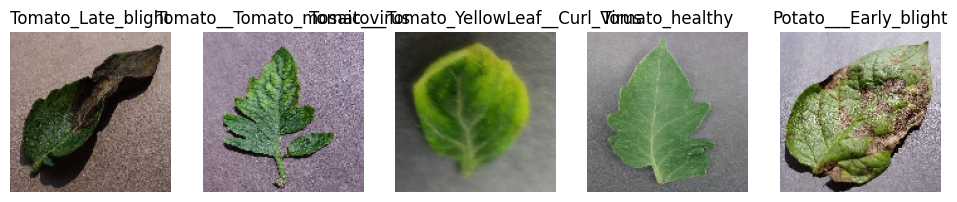

In [ ]:
import matplotlib.pyplot as plt
import random

# Show 5 random training images
plt.figure(figsize=(12,5))
for i in range(5):
    idx = random.randint(0, X_train.shape[0]-1)
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[idx])
    plt.title(classes[y_train[idx]])
    plt.axis('off')
plt.show()


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense

input_img = Input(shape=(128,128,3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
del X_train, X_val, X_test
del y_train, y_val, y_test
import gc
gc.collect()


9191

In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 16  # small = safe

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./PlantVillage/PlantVillage",
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "./PlantVillage/PlantVillage",
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 20638 files belonging to 15 classes.
Using 14447 files for training.
Found 20638 files belonging to 15 classes.
Using 6191 files for validation.


In [ ]:
normalizer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalizer(x), normalizer(x)))
val_ds = val_ds.map(lambda x, y: (normalizer(x), normalizer(x)))


In [ ]:
epochs = 30

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.0089 - val_loss: 0.0032
Epoch 2/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 3/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 4/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 5/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - loss: 0.0022 - val_loss: 0.0026
Epoch 6/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 8/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 9/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 10/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 11/30
903/903 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 12/30
903/903 ━━━━━━━━━━

In [ ]:
# Take 1 batch from val_ds
for batch in val_ds.take(1):
    X_val_batch, _ = batch  # _ because labels are not needed for autoencoder

# Visualize 5 random images from this batch
n = 5
indices = random.sample(range(X_val_batch.shape[0]), n)
decoded_imgs = autoencoder.predict(X_val_batch[indices])

plt.figure(figsize=(12,5))
for i, idx in enumerate(indices):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_val_batch[idx].numpy())
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} Index out of range using input dim 4; input has only 4 dims [Op:StridedSlice] name: strided_slice/